# Notebook 03 — Species Distribution Model

This notebook trains a Random Forest species distribution model (SDM) for spotted lanternfly (*Lycorma delicatula*) and projects it across the GSMNP study area as a continuous habitat suitability surface.

The approach uses a presence-background framework: the 8,835 thinned SLF occurrence records from notebook 01 are treated as class 1 (presence), and 10,000 uniformly sampled random background points from the SE US calibration area are treated as class 0. A `RandomForestClassifier` learns to distinguish the environmental conditions at presence locations from the broader accessible environment. Its `predict_proba` output — the fraction of trees voting for presence — is used as a relative suitability score, not a calibrated probability.

Five predictors are used: precipitation, max temperature, mean temperature, min temperature, and elevation. Land cover is excluded from training because fetching NLCD across the full SE US training extent is impractical at notebook scope, and because NLCD at occurrence points would partly reflect observer clustering in developed areas rather than true SLF habitat preference.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import py3dep
from pyproj import Transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.inspection import PartialDependenceDisplay

## Load Presence Points

The 8,835 thinned occurrence records from notebook 01 are in EPSG:4326. Longitude and latitude are extracted as NumPy arrays — PRISM extraction, elevation queries, and spatial block assignment all operate on these directly.

In [2]:
presences = gpd.read_file('./data/slf_occurrences_cleaned.gpkg')
pres_lon = presences.geometry.x.values
pres_lat = presences.geometry.y.values
print(f"Presence points loaded: {len(presences):,}")

Presence points loaded: 8,835


## Background Points

Background points represent the environmental space available to SLF within its accessible area — the SE US calibration region bounded approximately by -88.4° to -75.0° lon and 33.8° to 42.0° lat. This is the region where SLF has had the opportunity to spread and be detected. Drawing background from this extent captures the full environmental gradient the model needs to contrast against presence conditions without reaching into environments SLF has never encountered.

We generate 12,000 candidates to allow for attrition from ocean pixels and PRISM coverage gaps, then keep the first 10,000 valid points after environmental extraction. The resulting 1:1 presence-to-background ratio works well for Random Forest — equal class prevalence prevents the model from defaulting to background predictions.

In [3]:
rng = np.random.default_rng(42)
bg_bbox = (-88.4, 33.8, -75.0, 42.0)  # lon_min, lat_min, lon_max, lat_max
n_bg_candidates = 12_000

bg_lon = rng.uniform(bg_bbox[0], bg_bbox[2], n_bg_candidates)
bg_lat = rng.uniform(bg_bbox[1], bg_bbox[3], n_bg_candidates)
print(f"Background candidates generated: {n_bg_candidates:,}")

Background candidates generated: 12,000


## Extract PRISM Climate Values

Climate values at all training coordinates are extracted from the full-US PRISM rasters on disk. `rasterio.sample()` takes a list of (x, y) coordinate pairs and returns the raster value at each location — no API calls, just a direct pixel lookup.

PRISM rasters are in EPSG:4269 (NAD83 geographic). Training coordinates are in EPSG:4326 (WGS84). The two datums differ by less than 1 m in the continental US — negligible at 800 m PRISM resolution — but we transform properly regardless. Points outside PRISM coverage return the nodata value (-9999.0), which is replaced with NaN.

In [4]:
transformer_4269 = Transformer.from_crs("EPSG:4326", "EPSG:4269", always_xy=True)

all_lon = np.concatenate([pres_lon, bg_lon])
all_lat = np.concatenate([pres_lat, bg_lat])
all_x, all_y = transformer_4269.transform(all_lon, all_lat)
coords_4269 = list(zip(all_x.tolist(), all_y.tolist()))

prism_vars = {
    'ppt':   './data/prism/prism_ppt_us_30s_2020_avg_30y.tif',
    'tmax':  './data/prism/prism_tmax_us_30s_2020_avg_30y.tif',
    'tmean': './data/prism/prism_tmean_us_30s_2020_avg_30y.tif',
    'tmin':  './data/prism/prism_tmin_us_30s_2020_avg_30y.tif',
}

climate = {}
for var, path in prism_vars.items():
    with rasterio.open(path) as src:
        nodata_val = src.nodata
        vals = np.array([v[0] for v in src.sample(coords_4269)], dtype=float)
        if nodata_val is not None:
            vals[vals == nodata_val] = np.nan
    climate[var] = vals
    print(f"{var}: {np.isnan(vals).sum():,} nodata out of {len(vals):,}")

ppt: 578 nodata out of 20,835
tmax: 578 nodata out of 20,835
tmean: 578 nodata out of 20,835
tmin: 578 nodata out of 20,835


## Extract Elevation

Point elevations are queried from the USGS 3DEP service via `py3dep`. This is the same data source used to build the elevation layer in the prediction stack, so training and prediction values come from a consistent source.

Requests are batched in chunks of 1,000 to avoid timeouts. With ~20,835 total training coordinates, this is approximately 21 batches.

In [6]:
# py3dep renamed get_elev_bycoords -> elevation_bycoords in 0.15+
_get_elev = getattr(py3dep, 'elevation_bycoords', None) or getattr(py3dep, 'get_elev_bycoords')

coords_4326 = list(zip(all_lon.tolist(), all_lat.tolist()))
chunk_size = 1000
elevations = []

for i in range(0, len(coords_4326), chunk_size):
    chunk = coords_4326[i:i + chunk_size]
    elev = _get_elev(chunk, crs='EPSG:4326')
    # handle Series, array, or plain list return types
    elevations.extend(elev.tolist() if hasattr(elev, 'tolist') else list(elev))
    if (i // chunk_size + 1) % 5 == 0:
        print(f"  {i + chunk_size:,} / {len(coords_4326):,}")

elevations = np.array(elevations, dtype=float)
print(f"\nElevation complete: {len(elevations):,} points, {np.isnan(elevations).sum():,} nodata")

  5,000 / 20,835
  10,000 / 20,835
  15,000 / 20,835
  20,000 / 20,835

Elevation complete: 20,835 points, 0 nodata


## Assemble Training Matrix

Climate and elevation values are combined into a single DataFrame. Rows with any missing value are dropped — these are background candidates that landed over water or outside PRISM coverage. The background set is trimmed to exactly 10,000 valid points. Presence points were thinned and filtered in notebook 01 within the PRISM-covered SE US, so few if any will be dropped.

In [7]:
n_pres = len(pres_lon)
feature_cols = ['ppt', 'tmax', 'tmean', 'tmin', 'elevation']

df = pd.DataFrame({
    'ppt':       climate['ppt'],
    'tmax':      climate['tmax'],
    'tmean':     climate['tmean'],
    'tmin':      climate['tmin'],
    'elevation': elevations,
    'lon':       all_lon,
    'lat':       all_lat,
    'label':     np.concatenate([np.ones(n_pres), np.zeros(n_bg_candidates)]),
})

pres_df = df[df['label'] == 1].dropna(subset=feature_cols)
bg_df   = df[df['label'] == 0].dropna(subset=feature_cols).iloc[:10_000]

train_df = pd.concat([pres_df, bg_df], ignore_index=True)
X = train_df[feature_cols].values
y = train_df['label'].values
print(f"Presence: {(y == 1).sum():,}  Background: {(y == 0).sum():,}  Total: {len(y):,}")

Presence: 8,835  Background: 10,000  Total: 18,835


## Spatial Block Cross-Validation

A random train/test split would put geographically adjacent points in different folds, inflating AUC-ROC because nearby points share nearly identical environmental conditions. The model would memorize local feature space rather than generalize across geography — which is precisely what we need it to do when projecting into GSMNP.

Each point is assigned to a 2° × 2° geographic block by flooring its coordinates. At these latitudes, 2° spans approximately 150–220 km, exceeding the typical spatial autocorrelation range of the PRISM climate layers (~50–100 km). `GroupKFold(5)` partitions blocks into 5 folds such that no block spans a fold boundary, creating genuinely independent holdout regions.

Benchmarks: above 0.85 is strong for a 5-predictor spatial block model; above 0.75 is acceptable on first fit. Below 0.70 would suggest the predictors aren't capturing SLF's niche.

In [8]:
lon_arr = train_df['lon'].values
lat_arr = train_df['lat'].values
blocks = (np.floor(lon_arr / 2.0) * 2).astype(int) * 10000 + (np.floor(lat_arr / 2.0) * 2).astype(int)

cv = GroupKFold(n_splits=5)
rf = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)
auc_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=blocks)):
    rf.fit(X[train_idx], y[train_idx])
    prob = rf.predict_proba(X[test_idx])[:, 1]
    auc = roc_auc_score(y[test_idx], prob)
    auc_scores.append(auc)
    print(f"Fold {fold + 1}: AUC-ROC = {auc:.4f}  (train={len(train_idx):,}, test={len(test_idx):,})")

print(f"\nMean AUC-ROC: {np.mean(auc_scores):.4f} \u00b1 {np.std(auc_scores):.4f}")

Fold 1: AUC-ROC = 0.6434  (train=15,073, test=3,762)
Fold 2: AUC-ROC = 0.8614  (train=15,074, test=3,761)
Fold 3: AUC-ROC = 0.6739  (train=15,051, test=3,784)
Fold 4: AUC-ROC = 0.6238  (train=15,069, test=3,766)
Fold 5: AUC-ROC = 0.9327  (train=15,073, test=3,762)

Mean AUC-ROC: 0.7470 ± 0.1255


## Fit Final Model

Cross-validation used each fold's training subset, leaving the model fitted on roughly 80% of the data. The final model for prediction is refitted on all training points — it has seen the full environmental space and will generalize better than any single fold model.

In [9]:
rf.fit(X, y)
print(f"Final model: {rf.n_estimators} trees, fitted on {len(y):,} points "
      f"({(y == 1).sum():,} presence, {(y == 0).sum():,} background)")

Final model: 500 trees, fitted on 18,835 points (8,835 presence, 10,000 background)


## Feature Importance

`feature_importances_` reports the mean decrease in Gini impurity for each predictor, averaged across all 500 trees. This is a relative ranking of which variables the model most often split on to separate presence from background — not a measure of effect size or ecological causality. Redundant predictors will share importance between them.

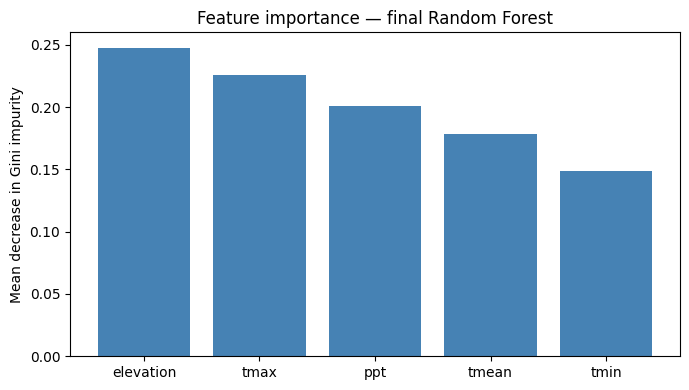

In [10]:
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]
labels = [feature_cols[i] for i in order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(labels)), importances[order], color='steelblue')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel('Mean decrease in Gini impurity')
ax.set_title('Feature importance — final Random Forest')
plt.tight_layout()
plt.show()

## Partial Dependence

Partial dependence plots show the marginal effect of each predictor on suitability, averaged over all other predictors and all training points. They reveal the shape of the learned response curve independent of the other variables' values.

For SLF, which established in mid-Atlantic lowlands with a moderate temperate climate, temperature predictors are expected to show peaked or monotonically positive responses within the training range, and elevation is expected to show a negative relationship with suitability given that presences cluster below 500 m. Unexpected shapes — flat responses or inversions — may indicate predictor collinearity or model artifacts worth investigating before notebook 04.

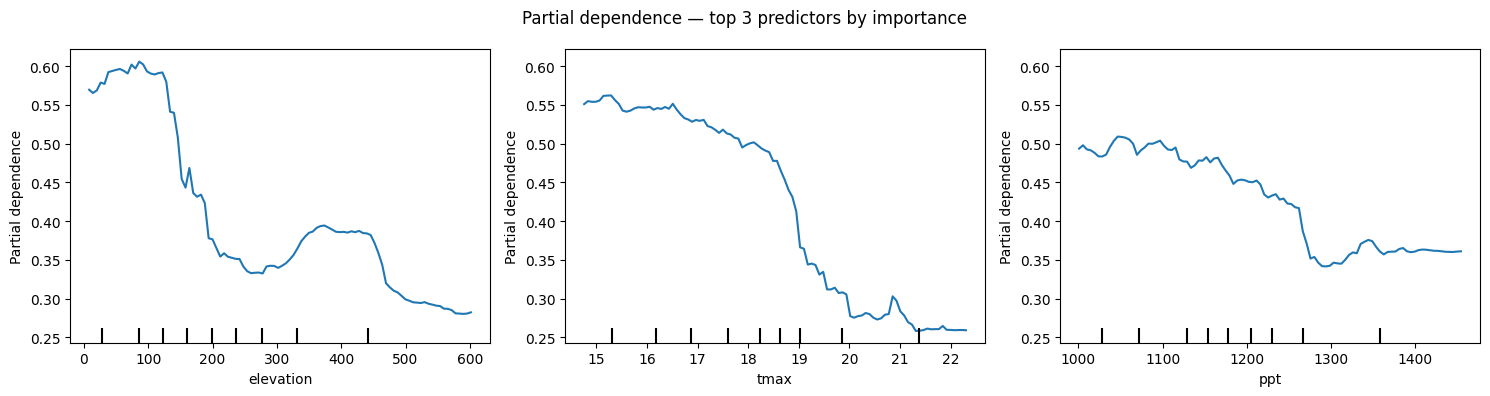

In [11]:
top_3 = np.argsort(rf.feature_importances_)[::-1][:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    rf, X, features=top_3, feature_names=feature_cols,
    ax=axes, kind='average'
)
fig.suptitle('Partial dependence — top 3 predictors by importance')
plt.tight_layout()
plt.show()

## Predict Habitat Suitability

The fitted model is applied to every valid pixel in the GSMNP study area. Bands 1–5 of `env_predictors.tif` (ppt, tmax, tmean, tmin, elevation) are read as a 5×H×W array. Band 6 (land cover) is skipped — the model was trained without it.

A valid-pixel mask is built from the intersection of finite values across all five predictor bands. In practice this is 81,715 pixels controlled by the PRISM coverage mask. Each valid pixel's five predictor values are passed through `predict_proba`, and the class-1 fraction (presence vote across 500 trees) is written to the corresponding location in the output raster. Pixels outside the valid mask are written as NaN.

The output grid matches `env_predictors.tif` exactly — same transform, CRS, and dimensions. This ensures it can be overlaid with the predictor stack and NPS layers in notebook 04 without any reprojection.

In [12]:
stack_path = './data/env_stack/env_predictors.tif'
out_path   = './data/suitability.tif'

with rasterio.open(stack_path) as src:
    X_stack = src.read([1, 2, 3, 4, 5]).astype(np.float32)  # (5, H, W)
    meta = src.meta.copy()

H, W = X_stack.shape[1], X_stack.shape[2]
valid = ~np.isnan(X_stack).any(axis=0)      # (H, W) — True where all 5 bands have data
X_flat = X_stack[:, valid].T                # (n_valid, 5)
print(f"Valid pixels: {valid.sum():,}  (grid: {H}\u00d7{W})")

proba = rf.predict_proba(X_flat)[:, 1].astype(np.float32)

suitability = np.full((H, W), np.nan, dtype=np.float32)
suitability[valid] = proba

meta.update(count=1, dtype='float32', nodata=float('nan'))
with rasterio.open(out_path, 'w', compress='lzw', **meta) as dst:
    dst.write(suitability[np.newaxis, :, :])
    dst.update_tags(description='SLF habitat suitability (Random Forest, 5 climate+elevation predictors)')

print(f"Saved: {out_path}")
print(f"Suitability range: {proba.min():.3f} \u2013 {proba.max():.3f}  mean: {proba.mean():.3f}")

Valid pixels: 81,715  (grid: 286×437)
Saved: ./data/suitability.tif
Suitability range: 0.000 – 0.458  mean: 0.040
